In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.rcParams['font.size'] = 12

In [3]:
output_dir = "./data"
file_name = "housing.csv"

path = kagglehub.dataset_download(
    handle="camnugent/california-housing-prices",
    output_dir=output_dir,
)

In [4]:
RANDOM_STATE = 42

In [5]:
df = pd.read_csv(f"{output_dir}/{file_name}")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [6]:
len(df)

20640

In [7]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [8]:
TARGET = "median_house_value"

In [9]:
print(f"{'Column':<25}Nans (%)")
print("-----------------------------")
for c in df.columns:
    print(f"{c:<25}{len(df[pd.isna(df[c])])}")

Column                   Nans (%)
-----------------------------
longitude                0
latitude                 0
housing_median_age       0
total_rooms              0
total_bedrooms           207
population               0
households               0
median_income            0
median_house_value       0
ocean_proximity          0


In [10]:
# Drop rows where "total_bedrooms" = NaN
df = df[pd.isna(df["total_bedrooms"]) != True]

In [11]:
categorial_features = df.select_dtypes(include=["object"]).columns
print(categorial_features)

Index(['ocean_proximity'], dtype='object')


In [12]:
X = df.drop(labels=[TARGET], axis=1)
y = df[TARGET]

In [13]:
from sklearn.preprocessing import LabelEncoder

X1 = X.drop(labels=categorial_features, axis=1)
df1 = X1.join(y)
X1_values = X1.values

# TODO: the task was to use target encoding, not label encoding
X2 = X.copy()
for c in categorial_features:
    X2[c] = LabelEncoder().fit_transform(X[c].values)
df2 = X2.join(y)
X2_values = X2.values

X3 = pd.get_dummies(X, dtype=float)
df3 = X3.join(y)
X3_values = X3.values

X_values_list = [
    (X1_values, "No categorial"),
    (X2_values, "Label encoded"),
    (X3_values, "One hot encoded"),
]

In [14]:
def draw_heat_map(corr_matrix: pd.DataFrame) -> None:
    sns.heatmap(data=corr_matrix, cmap='coolwarm', annot=True, annot_kws={"fontsize": 5.5})

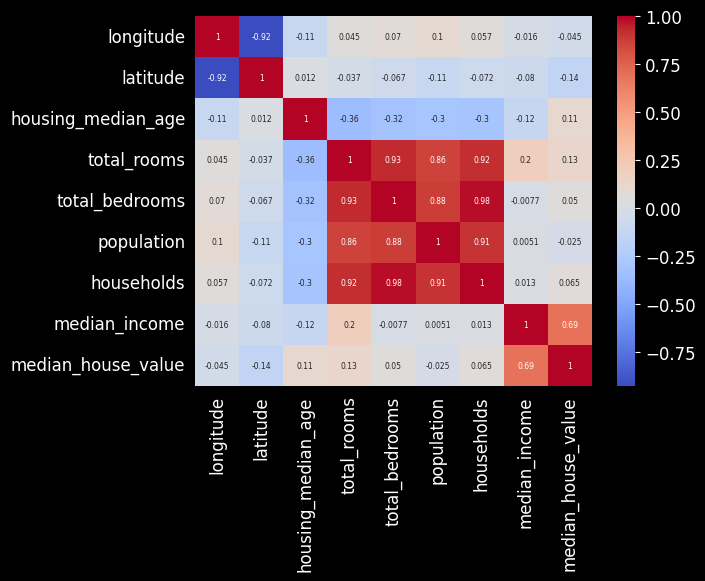

In [15]:
draw_heat_map(df1.corr())

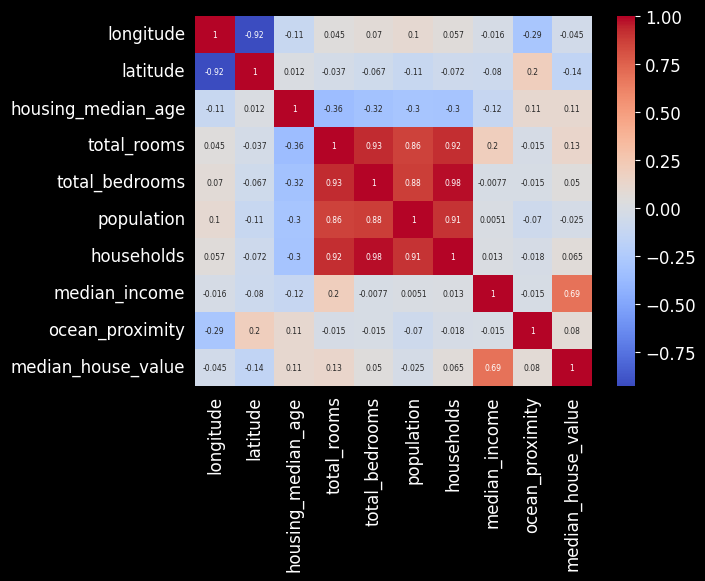

In [16]:
draw_heat_map(X2.join(y).corr())

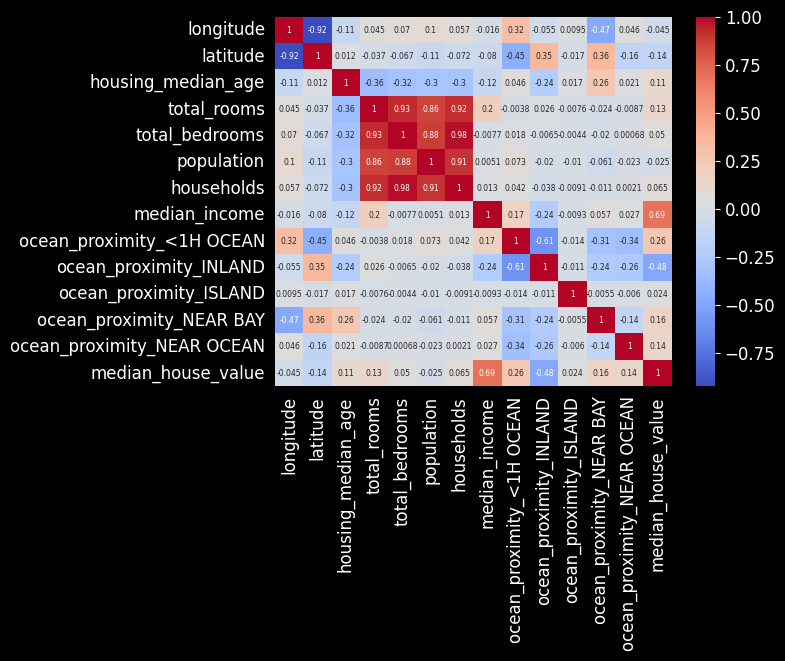

In [17]:
draw_heat_map(X3.join(y).corr())

In [18]:
from sklearn.model_selection import train_test_split

y_values = y.values

data = []

for X_values, label in X_values_list:
    X_train, X_test, y_train, y_test = train_test_split(
        X_values, y_values,
        test_size=0.2,
        random_state=RANDOM_STATE,
        shuffle=True
    )
    data.append((
        X_train,
        y_train,
        X_test,
        y_test,
        label
    ))

In [19]:
from typing import Any
from sklearn.metrics import r2_score, root_mean_squared_error

def run_models(models: list[Any]) -> None:
    print(f"{'Type':<20}{'R2':<10}RMSE")
    print(f"-----------------------------------")
    for model, (X_train, y_train, X_test, y_test, label) in zip(models, data):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_true = y_test
        r2_test = r2_score(y_true, y_pred)
        rmse_test = root_mean_squared_error(y_true, y_pred)
        print(f"{label:<20}{round(r2_test, 6):<10}{round(rmse_test):<25}")

In [20]:
from sklearn.linear_model import LinearRegression

run_models([LinearRegression()] * 3)

Type                R2        RMSE
-----------------------------------
No categorial       0.640087  70156                    
Label encoded       0.639924  70172                    
One hot encoded     0.64884   69298                    


In [21]:
from sklearn.ensemble import GradientBoostingRegressor

# TODO: fit gradient boosting only on categorial features to see, whether they are informative or not

# TODO: default values of n_estimators (100) is very small, it should be more
#  so redo the cross validation for obtaining best (n_estimators, max_depth) values
run_models([
    GradientBoostingRegressor(random_state=RANDOM_STATE, max_depth=7),
    GradientBoostingRegressor(random_state=RANDOM_STATE, max_depth=6),
    GradientBoostingRegressor(random_state=RANDOM_STATE, max_depth=9),
])

Type                R2        RMSE
-----------------------------------
No categorial       0.829356  48307                    
Label encoded       0.818452  49827                    
One hot encoded     0.834099  47631                    


In [22]:
from sklearn.ensemble import RandomForestRegressor

# TODO: default values of n_estimators (100) is very small, it should be more
#  so redo the cross validation for obtaining best (n_estimators, max_depth) values

run_models([
    RandomForestRegressor(random_state=RANDOM_STATE, max_depth=20),
    RandomForestRegressor(random_state=RANDOM_STATE, max_depth=21),
    RandomForestRegressor(random_state=RANDOM_STATE, max_depth=18),
])

Type                R2        RMSE
-----------------------------------
No categorial       0.823505  49128                    
Label encoded       0.820637  49526                    
One hot encoded     0.824886  48936                    


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# TODO: parameters are not optimal from the cross-validation

mlp_regressors = [
    MLPRegressor(learning_rate_init=0.1, batch_size=64, hidden_layer_sizes=(128, 64), max_iter=500),
    MLPRegressor(learning_rate_init=0.1, batch_size=64, hidden_layer_sizes=(128, 64), max_iter=500),
    MLPRegressor(learning_rate_init=0.1, batch_size=64, hidden_layer_sizes=(128, 64), max_iter=500),
]

pipelines = [Pipeline([
    ("scaler", StandardScaler()),
    ("estimator", m)]
) for m in mlp_regressors]

run_models(pipelines)

Type                R2        RMSE
-----------------------------------
No categorial       0.813579  50491                    
Label encoded       0.797497  52624                    
One hot encoded     0.803798  51799                    


In [24]:
def draw_explained_variance(data: dict, colors: np.ndarray, pc_number: int) -> None:
    plt.rcParams['font.size'] = 20

    fig, ax = plt.subplots(layout="constrained", figsize=(17, 10))

    x = np.arange(pc_number)
    width = 0.25
    multiplier = 0

    for color, (attribute, measurement) in zip(colors, data.items()):
        offset = width * multiplier
        _ = ax.bar(x + offset, measurement, width, label=attribute, color=color)
        multiplier += 1

    ax.set_ylabel("Explained Variance (%)")
    ax.set_title("Explained Variance for different encodings")
    ax.set_xticks(x + width, [f"PC{i+1}" for i in range(pc_number)])
    ax.legend()
    plt.show()


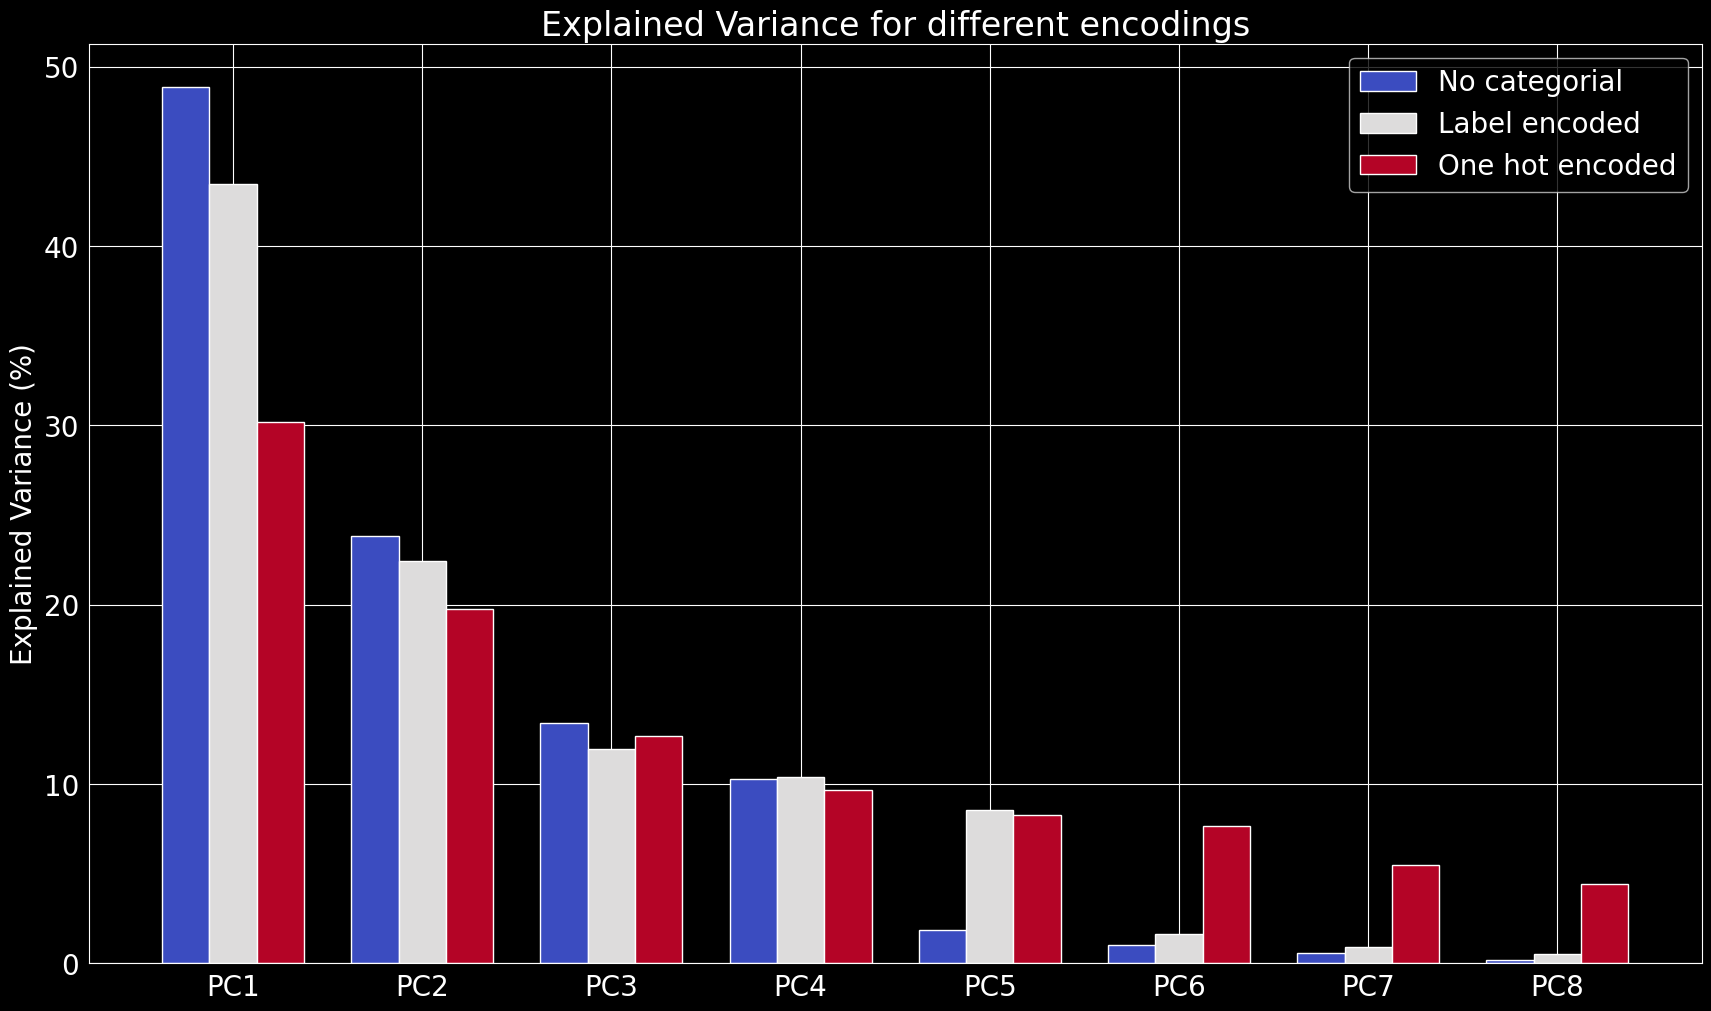

In [25]:
from sklearn.decomposition import PCA
import matplotlib as mpl

x_labels = list(map(lambda it: it[4], data))
explained_variance = {l:[] for l in x_labels}

cmap = mpl.colormaps["coolwarm"]
colors = cmap(np.linspace(0, 1, len(x_labels)))

pc_number = min(len(X1.columns), len(X2.columns), len(X3.columns))

pipelines = []

for Xi, label in X_values_list:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA())
    ])
    pipeline.fit(Xi)
    pipelines.append(pipeline)
    pca = pipeline["pca"]
    explained_variance[label] = (100 * pca.explained_variance_ratio_[:pc_number]).round(2)

draw_explained_variance(explained_variance, colors, pc_number)

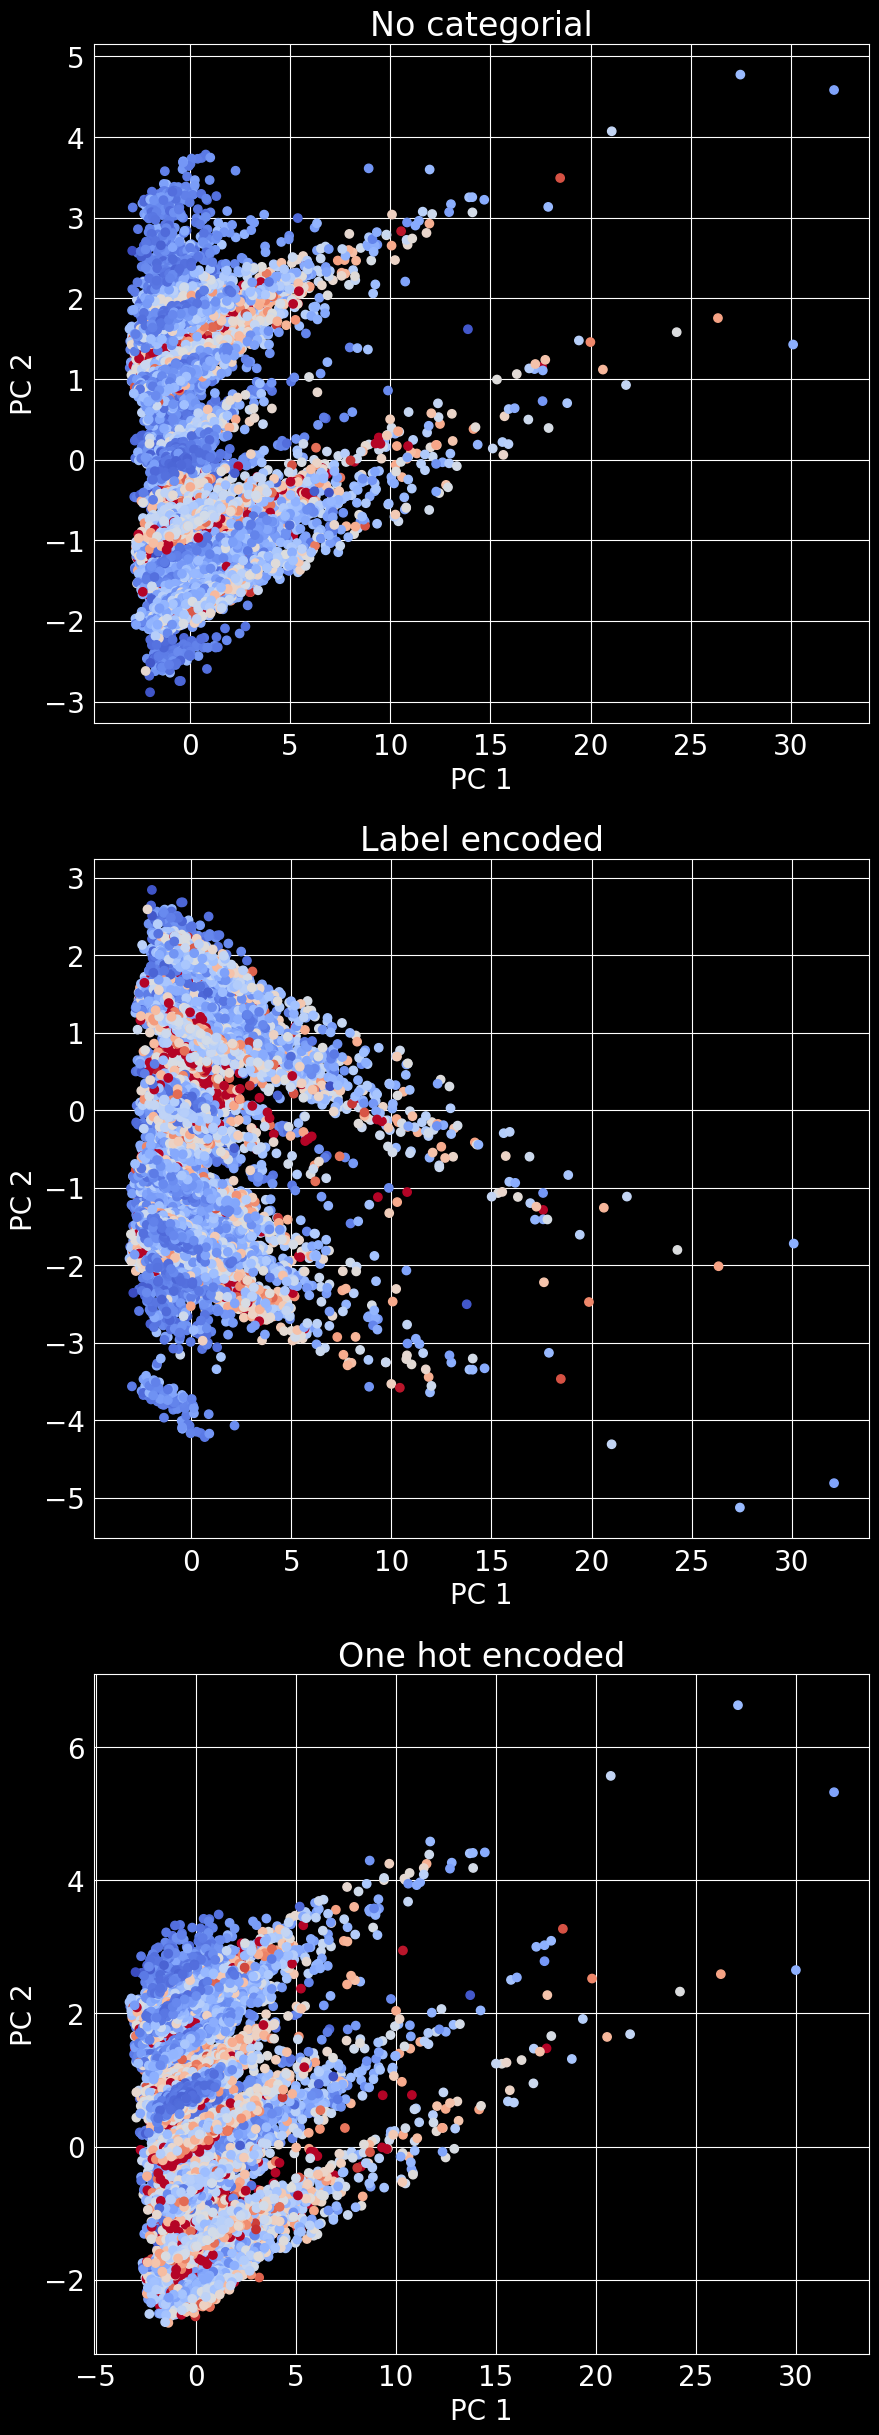

In [28]:
fig, sub = plt.subplots(3, 1, figsize=(10, 30))

for pipeline, (Xi, label), ax in zip(pipelines, X_values_list, sub.flatten()):
    Xi_reduced = pipeline.transform(Xi)
    ax.scatter(
        Xi_reduced[:, 0],
        Xi_reduced[:, 1],
        c=y_values,
        cmap="coolwarm",
    )
    ax.set_title(label)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")

plt.show()